# News Topic Classification with DistilBERT

Fine-tuning `distilbert-base-uncased` on the AG News benchmark — 120,000 training samples across four categories: **World**, **Sports**, **Business**, and **Sci/Tech**. The pipeline covers tokenization, fine-tuning with the HuggingFace Trainer API, evaluation with per-class metrics, and token-level attention interpretability.

## 1 · Setup

In [1]:
import warnings, logging, os
warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

!pip install transformers datasets -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})

LABEL_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']
MODEL_NAME  = 'distilbert-base-uncased'
MAX_LEN     = 128
BATCH_TRAIN = 32
BATCH_EVAL  = 64
EPOCHS      = 3
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128


## 2 · Data

AG News is a standard NLP benchmark derived from the AG corpus of news articles. The dataset is perfectly balanced — 30,000 training samples per class — making it a clean testbed for classification. We load it directly from the HuggingFace Hub.

In [3]:
dataset  = load_dataset('ag_news')
train_df = pd.DataFrame(dataset['train'])
test_df  = pd.DataFrame(dataset['test'])

train_df['label_name']   = train_df['label'].map(LABEL_NAMES.__getitem__)
train_df['word_count']   = train_df['text'].str.split().str.len()
test_df['label_name']    = test_df['label'].map(LABEL_NAMES.__getitem__)

print(f'Train : {len(train_df):,} samples')
print(f'Test  : {len(test_df):,} samples')
train_df[['label_name', 'text', 'word_count']].head(4)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train : 120,000 samples
Test  : 7,600 samples


,label_name,text,word_count
0,Business,Wall St. Bears Claw Back Into the Black (Reute...,21
1,Business,Carlyle Looks Toward Commercial Aerospace (Reu...,36
2,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...,36
3,Business,Iraq Halts Oil Exports from Main Southern Pipe...,36


### Exploratory Analysis

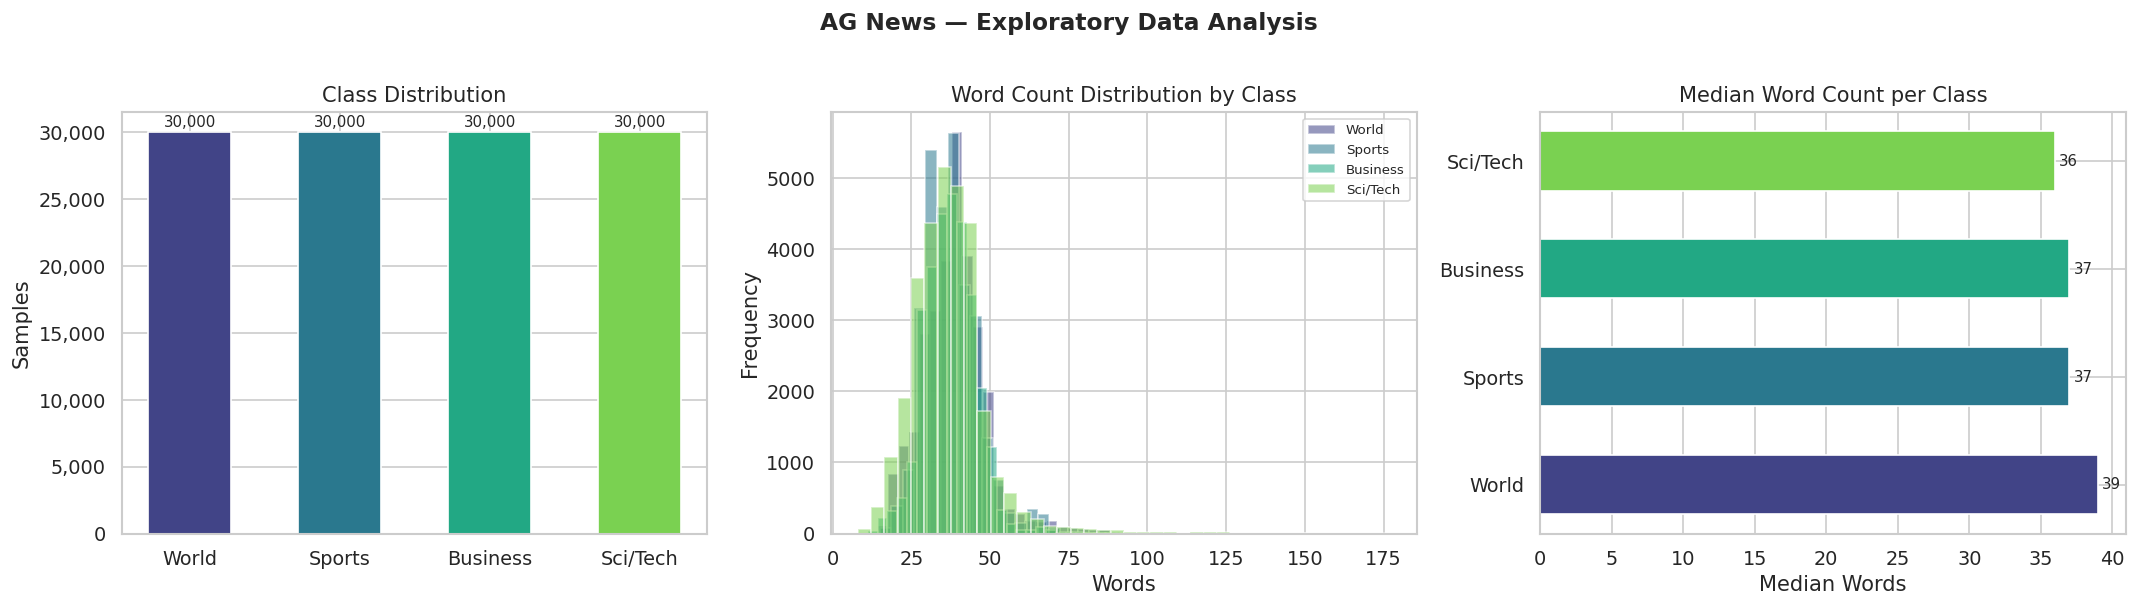

In [4]:
PALETTE = dict(zip(LABEL_NAMES, sns.color_palette('viridis', 4)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AG News — Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.01)

counts = train_df['label_name'].value_counts().reindex(LABEL_NAMES)
bars = axes[0].bar(counts.index, counts.values, color=[PALETTE[l] for l in counts.index], width=0.55)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Samples')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

for label in LABEL_NAMES:
    axes[1].hist(train_df[train_df['label_name'] == label]['word_count'],
                 bins=40, alpha=0.55, label=label, color=PALETTE[label])
axes[1].set_title('Word Count Distribution by Class')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)

stats = train_df.groupby('label_name')['word_count'].median().reindex(LABEL_NAMES)
axes[2].barh(stats.index, stats.values, color=[PALETTE[l] for l in stats.index], height=0.55)
axes[2].set_title('Median Word Count per Class')
axes[2].set_xlabel('Median Words')
for i, v in enumerate(stats.values):
    axes[2].text(v + 0.3, i, f'{v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 3 · Tokenization

DistilBERT uses WordPiece tokenization. Inputs are truncated to 128 tokens — sufficient to cover the 95th percentile of article lengths in this dataset — and padded to a fixed length for batching efficiency.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LEN,
        padding='max_length',
    )

train_tok = dataset['train'].map(tokenize_batch, batched=True, desc='Tokenising train')
test_tok  = dataset['test'].map(tokenize_batch,  batched=True, desc='Tokenising test')

train_tok = train_tok.rename_column('label', 'labels')
test_tok  = test_tok.rename_column('label', 'labels')

train_tok.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_tok.set_format('torch',  columns=['input_ids', 'attention_mask', 'labels'])

sample = tokenizer.convert_ids_to_tokens(train_tok[0]['input_ids'][:15])
print('Sample tokens:', sample)

Sample tokens: ['[CLS]', 'wall', 'st', '.', 'bears', 'claw', 'back', 'into', 'the', 'black', '(', 'reuters', ')', 'reuters', '-']


## 4 · Fine-Tuning

DistilBERT is a distilled version of BERT with 66M parameters — 40% smaller and 60% faster while retaining 97% of BERT's performance on GLUE. We add a two-layer classification head on top of the `[CLS]` token representation and fine-tune the entire network end-to-end. Mixed precision (fp16) halves GPU memory usage without affecting convergence.

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label={i: l for i, l in enumerate(LABEL_NAMES)},
    label2id={l: i for i, l in enumerate(LABEL_NAMES)},
)

def compute_metrics(pred):
    y_true = pred.label_ids
    y_pred = np.argmax(pred.predictions, axis=1)
    return {
        'accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'f1_macro' : round(f1_score(y_true, y_pred, average='macro'), 4),
    }

args = TrainingArguments(
    output_dir              = './results',
    num_train_epochs        = EPOCHS,
    per_device_train_batch_size = BATCH_TRAIN,
    per_device_eval_batch_size  = BATCH_EVAL,
    eval_strategy           = 'epoch',
    save_strategy           = 'epoch',
    load_best_model_at_end  = True,
    metric_for_best_model   = 'f1_macro',
    greater_is_better       = True,
    warmup_ratio            = 0.06,
    weight_decay            = 0.01,
    logging_steps           = 200,
    fp16                    = True,
    report_to               = 'none',
)

trainer = Trainer(
    model           = model,
    args            = args,
    train_dataset   = train_tok,
    eval_dataset    = test_tok,
    compute_metrics = compute_metrics,
)

trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.367339,0.348308,0.939300,0.939300
2,0.254105,0.332630,0.945900,0.946000
3,0.136166,0.378205,0.944900,0.944900


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5625, training_loss=0.3105999652014838, metrics={'train_runtime': 2157.1482, 'train_samples_per_second': 166.887, 'train_steps_per_second': 2.608, 'total_flos': 1.192249110528e+16, 'train_loss': 0.3105999652014838, 'epoch': 3.0})

## 5 · Evaluation

Performance is reported with per-class precision, recall, and F1. Macro-averaged F1 is the primary metric — it weights all classes equally regardless of size, which matters for multi-class benchmarks. The confusion matrix is normalised by row to show the proportion of each true class that was correctly predicted.

In [8]:
output  = trainer.predict(test_tok)
y_pred  = np.argmax(output.predictions, axis=1)
y_true  = output.label_ids

print('=' * 58)
print(f'{"Classification Report":^58}')
print('=' * 58)
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4))

                  Classification Report                   
              precision    recall  f1-score   support

       World     0.9698    0.9468    0.9582      1900
      Sports     0.9879    0.9879    0.9879      1900
    Business     0.9204    0.9126    0.9165      1900
    Sci/Tech     0.9072    0.9363    0.9215      1900

    accuracy                         0.9459      7600
   macro avg     0.9463    0.9459    0.9460      7600
weighted avg     0.9463    0.9459    0.9460      7600



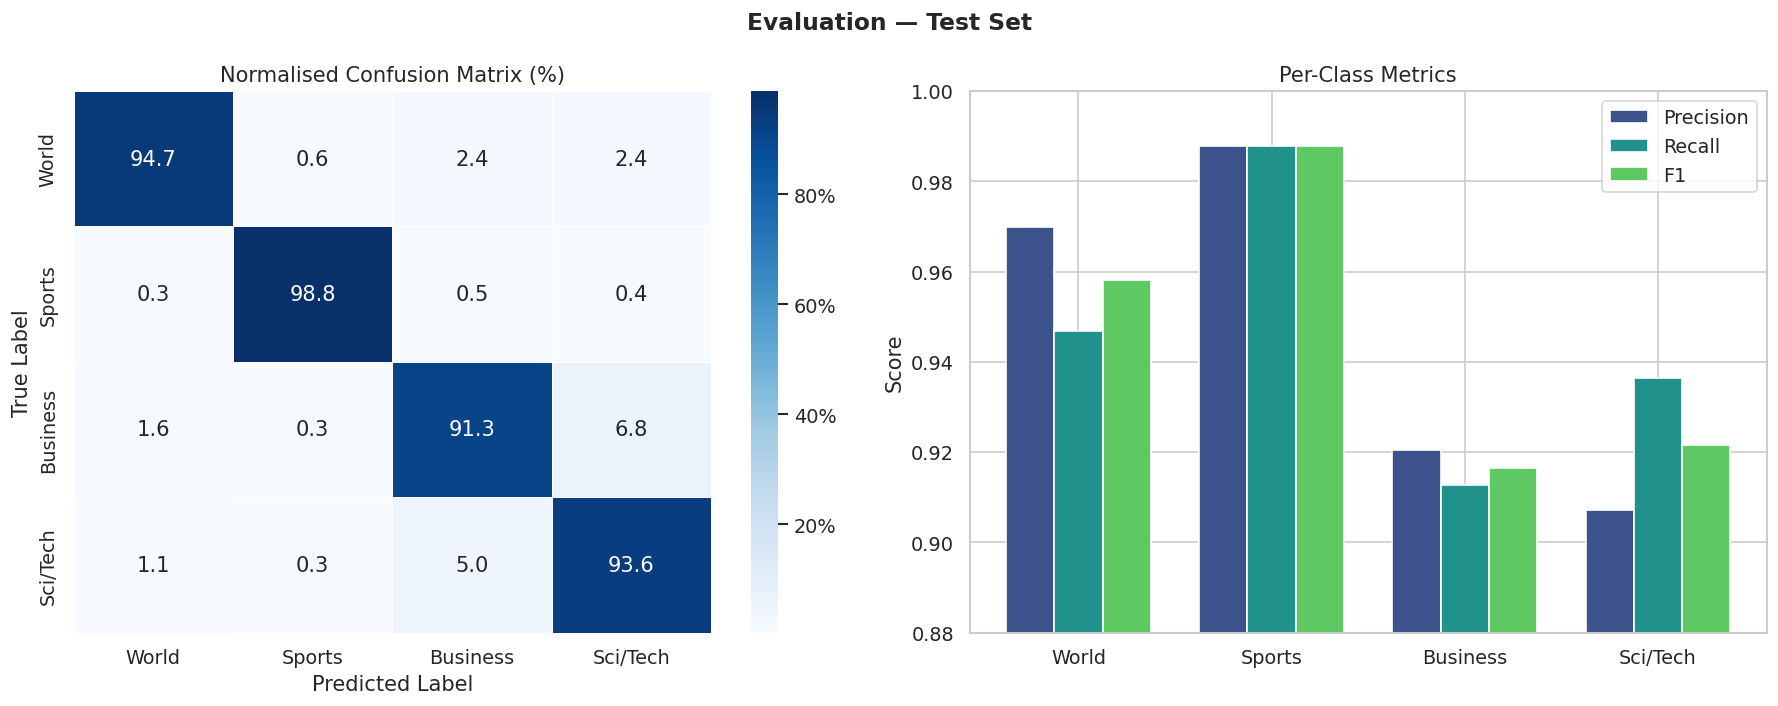

In [9]:
cm      = confusion_matrix(y_true, y_pred)
cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Evaluation — Test Set', fontsize=14, fontweight='bold')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.4, ax=axes[0], cbar_kws={'format': '%.0f%%'})
axes[0].set_title('Normalised Confusion Matrix (%)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

from sklearn.metrics import precision_recall_fscore_support
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred)
x = np.arange(len(LABEL_NAMES))
w = 0.25
axes[1].bar(x - w, p, w, label='Precision', color=sns.color_palette('viridis', 3)[0])
axes[1].bar(x,     r, w, label='Recall',    color=sns.color_palette('viridis', 3)[1])
axes[1].bar(x + w, f, w, label='F1',        color=sns.color_palette('viridis', 3)[2])
axes[1].set_xticks(x)
axes[1].set_xticklabels(LABEL_NAMES)
axes[1].set_ylim(0.88, 1.0)
axes[1].set_title('Per-Class Metrics')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.tight_layout()
plt.show()

## 6 · Attention Interpretability

Transformer attention weights capture which tokens the model focuses on when building its contextual representation. We average attention across all heads in the final encoder layer — the layer closest to the classification decision — and visualise the resulting token-level scores for one representative sample per class. Tokens with higher bars contributed more to the predicted label.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

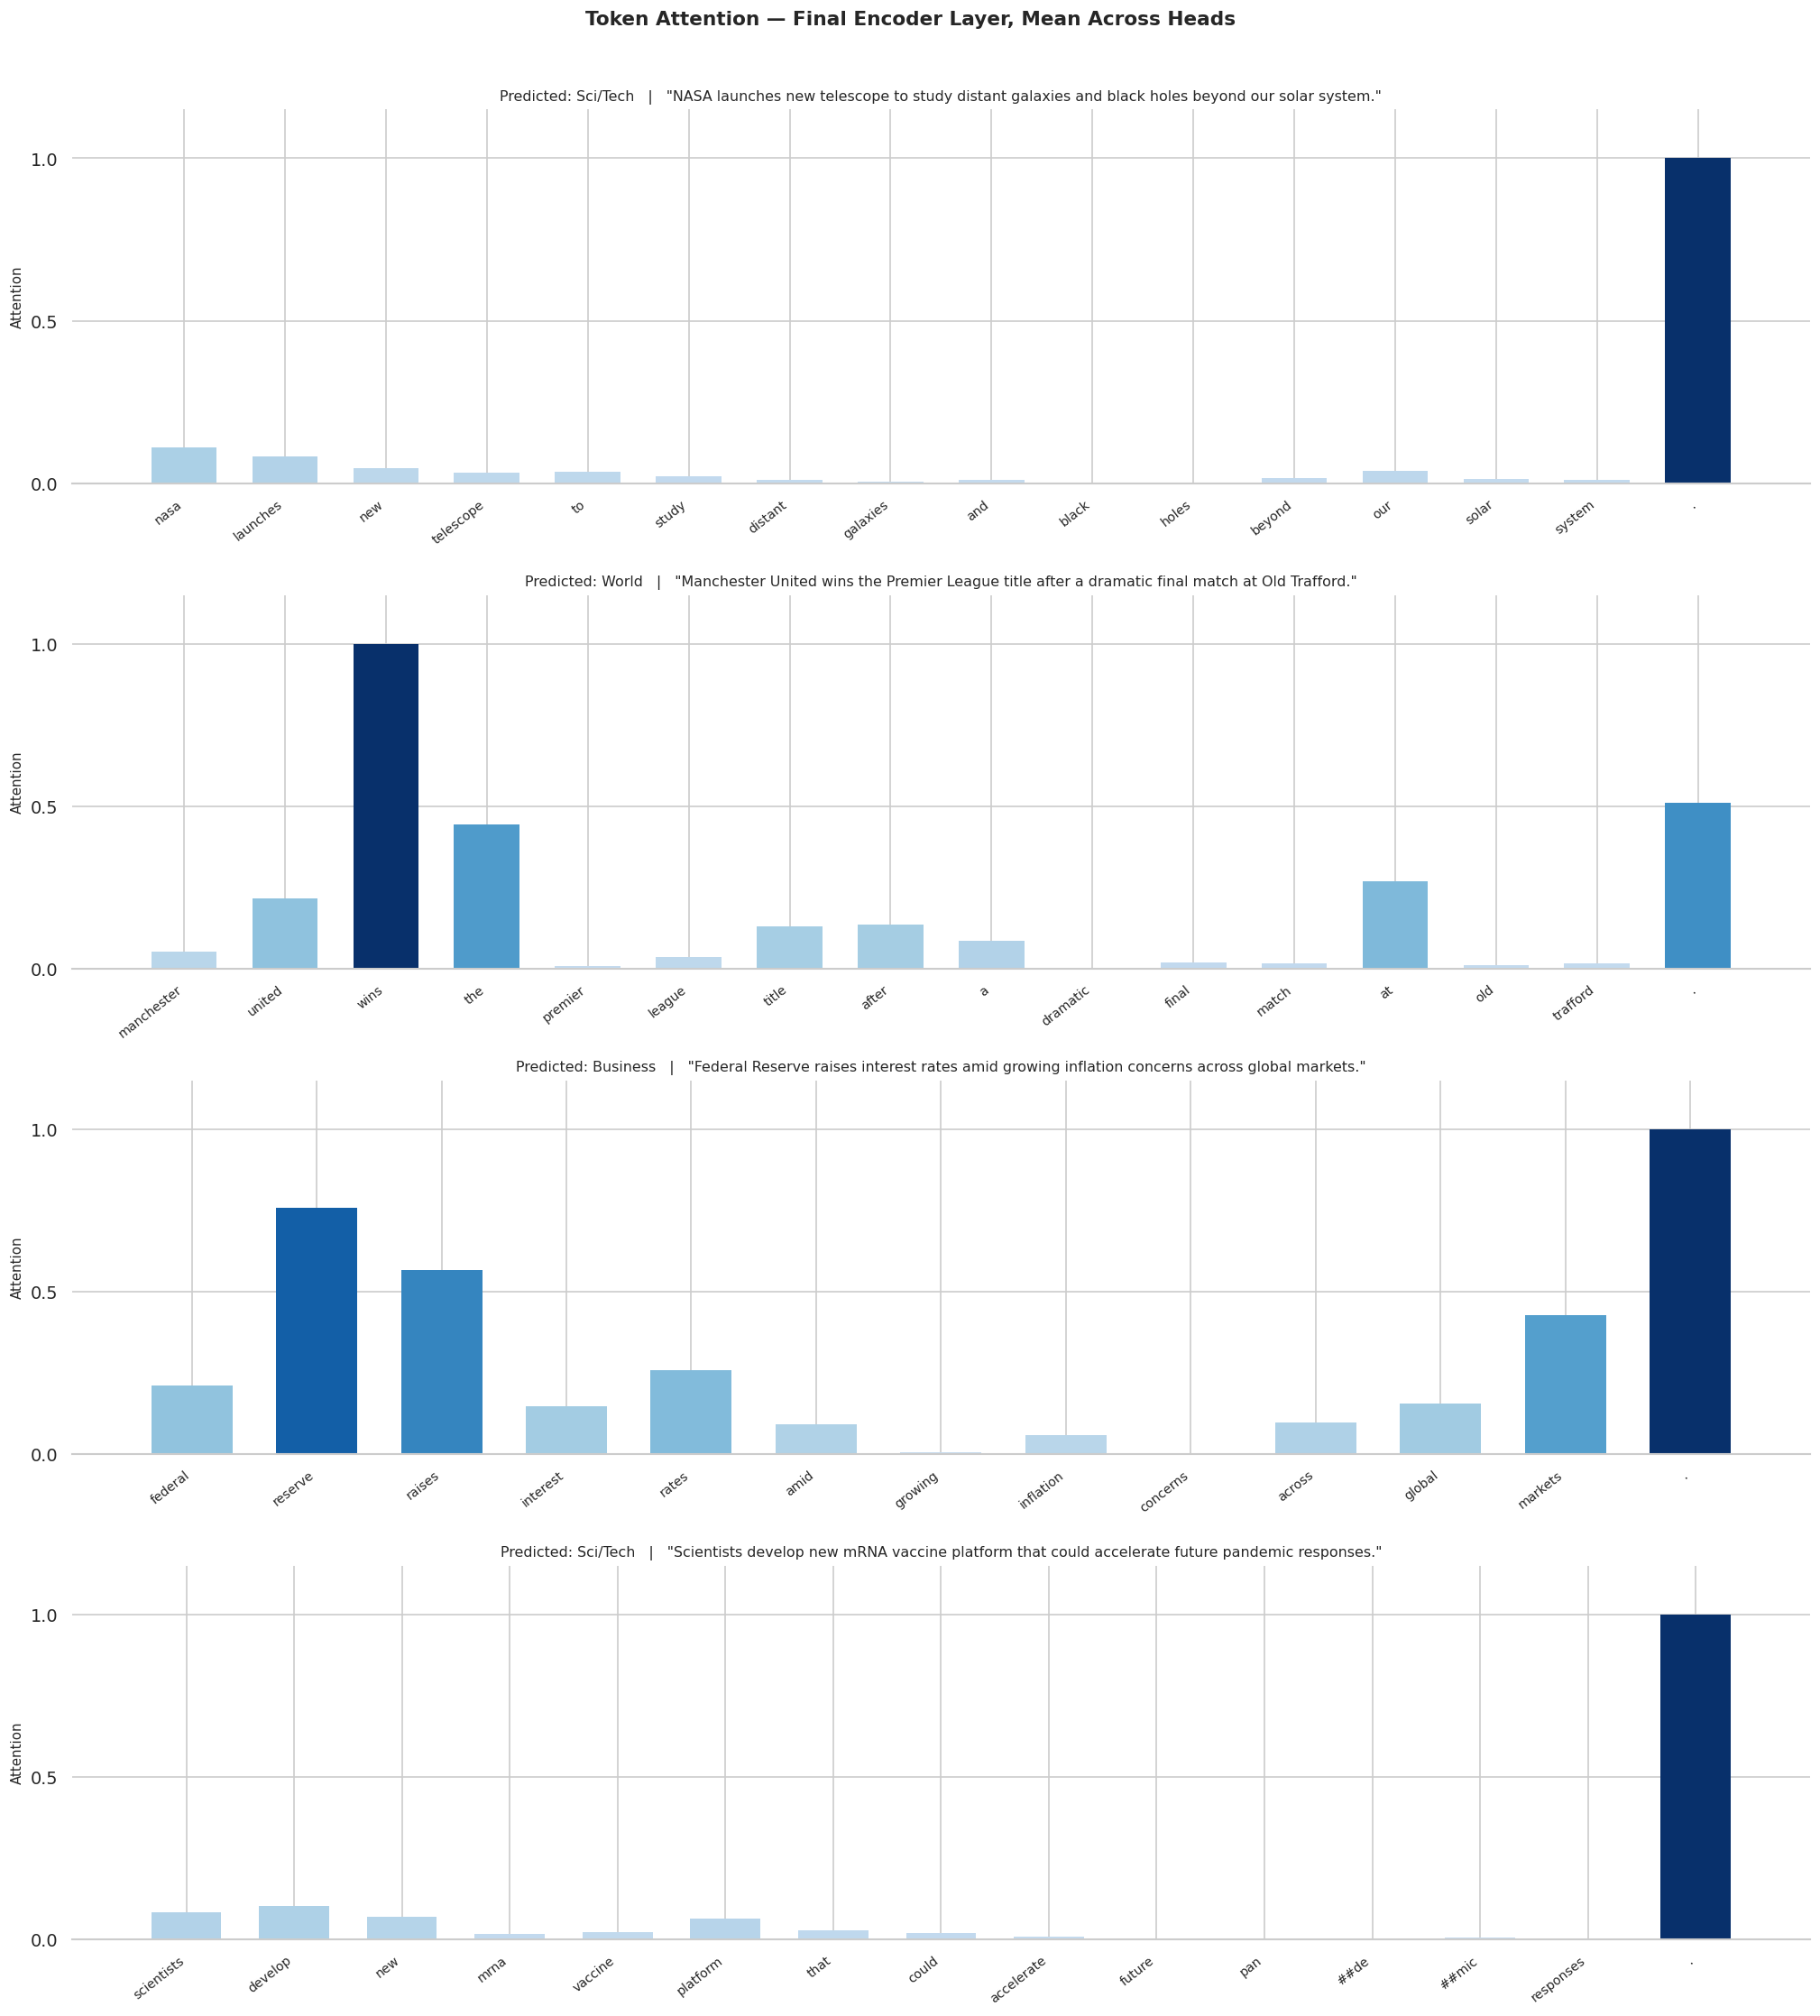

In [10]:
attn_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=4, attn_implementation='eager'
).to(DEVICE)
attn_model.load_state_dict(model.state_dict())
attn_model.eval()

SAMPLES = [
    'NASA launches new telescope to study distant galaxies and black holes beyond our solar system.',
    'Manchester United wins the Premier League title after a dramatic final match at Old Trafford.',
    'Federal Reserve raises interest rates amid growing inflation concerns across global markets.',
    'Scientists develop new mRNA vaccine platform that could accelerate future pandemic responses.',
]

cmap = plt.get_cmap('Blues')
fig, axes = plt.subplots(4, 1, figsize=(17, 19))
fig.suptitle('Token Attention — Final Encoder Layer, Mean Across Heads', fontsize=13, fontweight='bold')

for idx, text in enumerate(SAMPLES):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
    with torch.no_grad():
        out = attn_model(**inputs, output_attentions=True)

    attn    = out.attentions[-1][0].mean(dim=0)[0].cpu().numpy()
    tokens  = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    sep     = tokens.index('[SEP]')
    tokens  = tokens[1:sep]
    scores  = attn[1:len(tokens) + 1]
    scores  = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

    pred    = LABEL_NAMES[np.argmax(out.logits.cpu().numpy())]
    colors  = [cmap(0.25 + 0.75 * s) for s in scores]

    axes[idx].bar(range(len(tokens)), scores, color=colors, edgecolor='none', width=0.65)
    axes[idx].set_xticks(range(len(tokens)))
    axes[idx].set_xticklabels(tokens, rotation=38, ha='right', fontsize=8.5)
    axes[idx].set_title(f'Predicted: {pred}   |   "{text}"', fontsize=9.5, pad=6)
    axes[idx].set_ylabel('Attention', fontsize=9)
    axes[idx].set_ylim(0, 1.15)
    axes[idx].spines[['top', 'right', 'left']].set_visible(False)
    axes[idx].yaxis.set_major_locator(mticker.MultipleLocator(0.5))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()